/tmp/ipykernel_30044/871092373.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ativos, start='2018-01-01', end='2024-01-01')['Close']
[*********************100%***********************]  4 of 4 completed


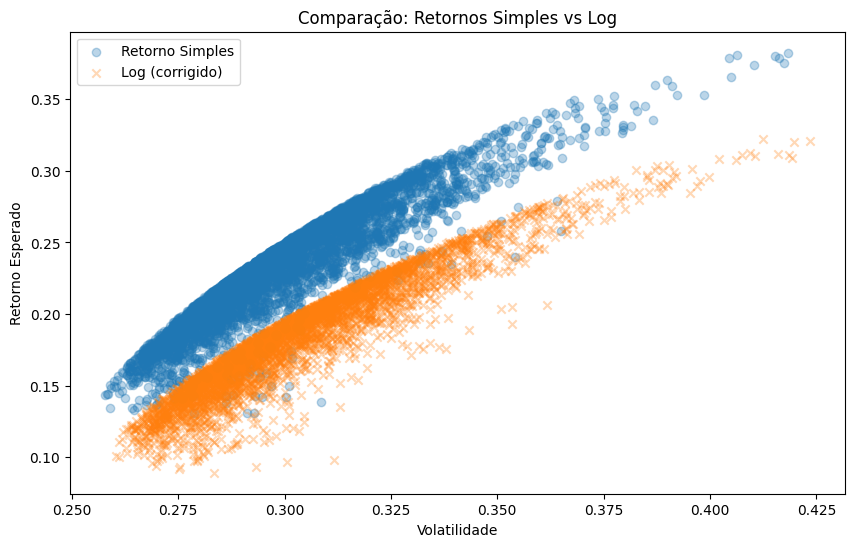

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# -----------------------------
# 1. Baixar dados
# -----------------------------
ativos = ['^BVSP', 'VALE3.SA', 'PETR4.SA', 'ITUB4.SA']
data = yf.download(ativos, start='2018-01-01', end='2024-01-01')['Close']

# remover NaN
data = data.dropna()

# -----------------------------
# 2. Retornos
# -----------------------------
ret_simples = data.pct_change().dropna()
ret_log = np.log(data / data.shift(1)).dropna()

# -----------------------------
# 3. Estatísticas
# -----------------------------
# anualização (252 dias úteis)
def stats(ret):
    mu = ret.mean() * 252
    cov = ret.cov() * 252
    return mu, cov

mu_s, cov_s = stats(ret_simples)
mu_l, cov_l = stats(ret_log)

# converter log -> simples (correção teórica)
mu_l_corr = np.exp(mu_l) - 1

# -----------------------------
# 4. Fronteira eficiente
# -----------------------------
def efficient_frontier(mu, cov, n_portfolios=5000):
    n = len(mu)
    results = []

    for _ in range(n_portfolios):
        w = np.random.random(n)
        w /= np.sum(w)

        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(cov, w)))

        results.append((vol, ret))

    return np.array(results)

ef_simples = efficient_frontier(mu_s, cov_s)
ef_log = efficient_frontier(mu_l_corr, cov_l)

# -----------------------------
# 5. Plot
# -----------------------------
plt.figure(figsize=(10,6))

plt.scatter(ef_simples[:,0], ef_simples[:,1], alpha=0.3, label='Retorno Simples')
plt.scatter(ef_log[:,0], ef_log[:,1], alpha=0.3, label='Log (corrigido)', marker='x')

plt.xlabel('Volatilidade')
plt.ylabel('Retorno Esperado')
plt.title('Comparação: Retornos Simples vs Log')
plt.legend()

plt.show()

/tmp/ipykernel_30044/1586228928.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ativos, start='2018-01-01', end='2024-01-01')['Close']
[*********************100%***********************]  3 of 3 completed


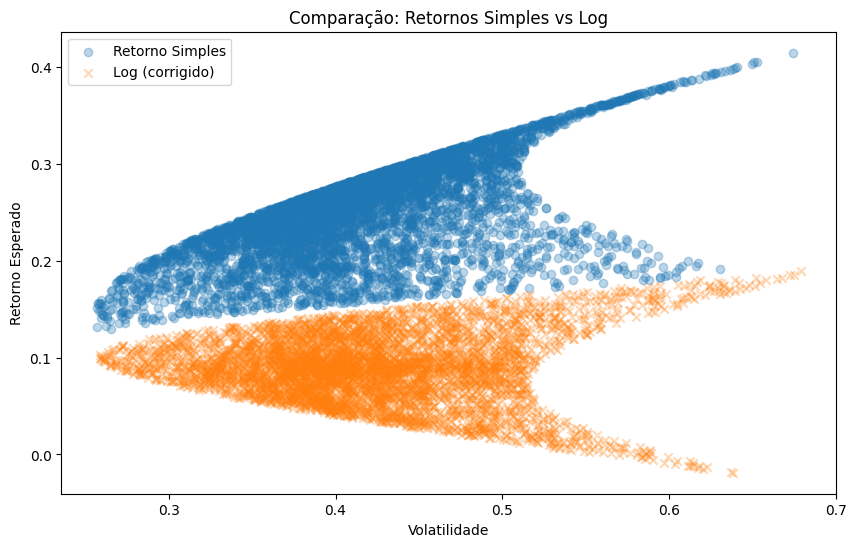

In [2]:
ativos = ['^BVSP', 'MGLU3.SA', 'BTC-USD']
data = yf.download(ativos, start='2018-01-01', end='2024-01-01')['Close']

# remover NaN
data = data.dropna()

# -----------------------------
# 2. Retornos
# -----------------------------
ret_simples = data.pct_change().dropna()
ret_log = np.log(data / data.shift(1)).dropna()

# -----------------------------
# 3. Estatísticas
# -----------------------------
# anualização (252 dias úteis)
def stats(ret):
    mu = ret.mean() * 252
    cov = ret.cov() * 252
    return mu, cov

mu_s, cov_s = stats(ret_simples)
mu_l, cov_l = stats(ret_log)

# converter log -> simples (correção teórica)
mu_l_corr = np.exp(mu_l) - 1

# -----------------------------
# 4. Fronteira eficiente
# -----------------------------
def efficient_frontier(mu, cov, n_portfolios=5000):
    n = len(mu)
    results = []

    for _ in range(n_portfolios):
        w = np.random.random(n)
        w /= np.sum(w)

        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(cov, w)))

        results.append((vol, ret))

    return np.array(results)

ef_simples = efficient_frontier(mu_s, cov_s)
ef_log = efficient_frontier(mu_l_corr, cov_l)

# -----------------------------
# 5. Plot
# -----------------------------
plt.figure(figsize=(10,6))

plt.scatter(ef_simples[:,0], ef_simples[:,1], alpha=0.3, label='Retorno Simples')
plt.scatter(ef_log[:,0], ef_log[:,1], alpha=0.3, label='Log (corrigido)', marker='x')

plt.xlabel('Volatilidade')
plt.ylabel('Retorno Esperado')
plt.title('Comparação: Retornos Simples vs Log')
plt.legend()

plt.show()